2025-10-21 创建
1. 解决风-潮-流-浪场的预报功能
2. 预留损失函数接口，为PINN做准备
3. 使用U-Net CNN神经网络

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
# 自建函数库
from main_python_MyFunctions import c_PickleHandler

d:\Softwares\Anaconda3\envs\cnn-model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 加载数据pkl文件
文件路径../datas/*.pkl

二维为*_2d.pkl；一维为*_piled.pkl

In [2]:
def f_load_pickle(file_path):
    handle = c_PickleHandler(file_path)
    data = handle.load_data()
    return data

if __name__=="__main__":    
    # 读取文件
    print('**loading files ...')

    # env_type = input("Please input the environment type (wave, surge, current): ")
    env_type = 'wave'
    
    # 读取mat文件
    wind_2d = f_load_pickle('../datas/wind_2d.pkl')
    if env_type == 'surge':
        surge_2d = f_load_pickle('../datas/surge_2d.pkl')
    elif env_type == 'current':
        surge_2d = f_load_pickle('../datas/surge_2d.pkl')
        current_2d = f_load_pickle('../datas/current_2d.pkl')
    elif env_type == 'wave':
        output_map_2d = f_load_pickle('../datas/wave_2d.pkl')

    # 查询surge_piled绝对值大于3的值的索引
    # 只保留绝对值小于3的风暴潮数据
    if env_type == 'surge':
        print('**cleaning surge data ...')
        surge_2d[np.abs(surge_2d) > 5] = 0
        output_map_2d = surge_2d
    elif env_type == 'current':
        print('**cleaning current data ...')
        current_2d[np.abs(surge_2d) > 5] = 0  # 注意：这里可能是打字错误，应为 current_2d

    # 正确提取 wind_2d 的 real 和 imag（关键修复：用 fields 访问）
    wind_real = wind_2d['real'].astype(np.float64)  # (110387, 56, 54), 纯 float64
    wind_imag = wind_2d['imag'].astype(np.float64)  # 同上
    wind_combined = np.stack([wind_real, wind_imag], axis=1)  # (110387, 2, 56, 54), 纯 float64

    # current 处理（如果适用）
    if env_type == 'current':
        current_real = current_2d['real'].astype(np.float64)
        current_imag = current_2d['imag'].astype(np.float64)
        output_map_2d = np.stack([current_real, current_imag], axis=1)

    # 网格数据
    x = np.arange(105.3, 116.01, 0.2, dtype = float)
    y = np.arange(12, 23.01, 0.2, dtype = float)
    X,Y = np.meshgrid(x, y)

    print("Data loading fixed: wind_combined dtype =", wind_combined.dtype)  # 应为 float64
    print("Data loading fixed: wind_combined shape =", wind_combined.shape)
    if env_type == 'surge':
        print("data type (surge): ",output_map_2d.dtype)
    elif env_type == 'current':
        print("data type (current): ",output_map_2d.dtype)
    elif env_type == 'wave':
        print("data type (wave): ",output_map_2d.dtype)

**loading files ...
Data loading fixed: wind_combined dtype = float64
Data loading fixed: wind_combined shape = (110387, 2, 56, 54)
data type (wave):  float64


In [3]:
# 检查原始数据中的 NaN/Inf
print("Wind data stats:")
print(f"NaN in wind_real: {np.any(np.isnan(wind_real))}")
print(f"Inf in wind_real: {np.any(np.isinf(wind_real))}")
print(f"NaN in wind_imag: {np.any(np.isnan(wind_imag))}")
print(f"Inf in wind_imag: {np.any(np.isinf(wind_imag))}")

print("\nOutput data stats:")
print(f"NaN in output_map_2d: {np.any(np.isnan(output_map_2d))}")
print(f"Inf in output_map_2d: {np.any(np.isinf(output_map_2d))}")

# 示例：打印有 NaN 的样本索引（如果有）
nan_wind_idx = np.where(np.isnan(wind_combined).any(axis=(1,2,3)))
nan_output_idx = np.where(np.isnan(output_map_2d).any(axis=(1,2)))
print(f"Wind NaN samples: {len(nan_wind_idx[0])}")
print(f"Output NaN samples: {len(nan_output_idx[0])}")

# 如果有 NaN，查看范围
print(f"Wind min/max: {np.nanmin(wind_combined):.2f} / {np.nanmax(wind_combined):.2f}")
print(f"Output min/max: {np.nanmin(output_map_2d):.2f} / {np.nanmax(output_map_2d):.2f}")

Wind data stats:
NaN in wind_real: False
Inf in wind_real: False
NaN in wind_imag: False
Inf in wind_imag: False

Output data stats:
NaN in output_map_2d: True
Inf in output_map_2d: False
Wind NaN samples: 0
Output NaN samples: 110387
Wind min/max: -66.59 / 64.03
Output min/max: 0.00 / 27.08


In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 清理 NaN/Inf：替换为 0（或均值），或删除样本
# 选项1: 替换（简单，保留所有样本）
wind_combined_clean = np.nan_to_num(wind_combined, nan=0.0, posinf=np.finfo(np.float64).max * 0.999, neginf=np.finfo(np.float64).min * 0.999)
output_map_2d_clean = np.nan_to_num(output_map_2d, nan=0.0, posinf=np.finfo(np.float64).max * 0.999, neginf=np.finfo(np.float64).min * 0.999)

# 选项2: 删除有 NaN 的样本（如果 NaN 少，推荐；否则用选项1）
# valid_idx_wind = ~np.isnan(wind_combined).any(axis=(1,2,3))
# valid_idx_output = ~np.isnan(output_map_2d).any(axis=(1,2))
# valid_idx = np.logical_and(valid_idx_wind, valid_idx_output)
# wind_combined_clean = wind_combined[valid_idx]
# output_map_2d_clean = output_map_2d[valid_idx]
# print(f"Removed {len(wind_combined) - len(wind_combined_clean)} invalid samples")

print("Cleaned data stats:")
print(f"NaN in cleaned wind: {np.any(np.isnan(wind_combined_clean))}")
print(f"NaN in cleaned output: {np.any(np.isnan(output_map_2d_clean))}")

# 现在归一化（sklearn 不会警告）
wind_flat = wind_combined_clean.reshape(len(wind_combined_clean), -1)
scaler_wind = StandardScaler()
wind_normalized = scaler_wind.fit_transform(wind_flat).reshape(wind_combined_clean.shape)

output_flat = output_map_2d_clean.reshape(len(output_map_2d_clean), -1)
scaler_output = StandardScaler()
output_normalized = scaler_output.fit_transform(output_flat).reshape(output_map_2d_clean.shape)

# 验证非 NaN
print(f"Normalized wind NaN: {np.any(np.isnan(wind_normalized))}")
print(f"Normalized output NaN: {np.any(np.isnan(output_normalized))}")
print(f"Wind normalized min/max: {np.nanmin(wind_normalized):.2f} / {np.nanmax(wind_normalized):.2f}")

Cleaned data stats:
NaN in cleaned wind: False
NaN in cleaned output: False
Normalized wind NaN: False
Normalized output NaN: False
Wind normalized min/max: -22.61 / 25.21


In [5]:
# 转换为 PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_tensor = torch.from_numpy(wind_normalized).float().to(device)
output_tensor = torch.from_numpy(output_normalized).float().unsqueeze(1).to(device)

# 检查 tensor 非 NaN
print("Tensor NaN check:")
print(f"Input NaN: {torch.any(torch.isnan(input_tensor))}")
print(f"Output NaN: {torch.any(torch.isnan(output_tensor))}")

print("input_tensor shape:", input_tensor.shape)
print("output_tensor shape:", output_tensor.shape)

# Dataset/DataLoader（不变）
dataset = TensorDataset(input_tensor, output_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print("Tensor conversion complete!")

Tensor NaN check:
Input NaN: False
Output NaN: False
input_tensor shape: torch.Size([110387, 2, 56, 54])
output_tensor shape: torch.Size([110387, 1, 56, 54])
Tensor conversion complete!


In [6]:
class DoubleConv(nn.Module):
    """双卷积块：不变"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """修正 Down：先 DoubleConv (生成高分辨率 skip)，后 MaxPool (返回低分辨率)"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = DoubleConv(in_channels, out_channels)
        self.max_pool = nn.MaxPool2d(2)  # stride=2, padding=0

    def forward(self, x):
        skip = self.double_conv(x)  # 高分辨率，用于 skip
        pooled = self.max_pool(skip)  # 低分辨率，传给下一层
        return pooled, skip  # 返回两者

class Up(nn.Module):
    """修正 Up：ConvTranspose 上采样 + pad/crop 匹配 skip 尺寸 + cat + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)  # 2x 上采样
        self.conv = DoubleConv(out_channels * 2, out_channels)  # *2 for cat

    def forward(self, x1, x2):  # x1: 低分辨率上采样输入, x2: 高分辨率 skip
        x1 = self.up(x1)  # 上采样 (e.g., 3x3 → 6x6)
        
        # 精确匹配尺寸：如果 x1 > x2，用 crop；如果 x1 < x2，用 pad (处理 floor)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        if diffY > 0:  # x1 H < x2 H, pad
            x1 = nn.functional.pad(x1, (0, 0, diffY // 2, diffY - diffY // 2))  # pad H (bottom/top)
        elif diffY < 0:  # x1 H > x2 H, crop
            x1 = x1[:, :, :x2.size()[2], :]
            
        if diffX > 0:  # x1 W < x2 W, pad
            x1 = nn.functional.pad(x1, (diffX // 2, diffX - diffX // 2, 0, 0))  # pad W (right/left)
        elif diffX < 0:  # x1 W > x2 W, crop
            x1 = x1[:, :, :, :x2.size()[3]]
        
        x = torch.cat([x2, x1], dim=1)  # 通道拼接 (现在尺寸匹配)
        return self.conv(x)

class UNet(nn.Module):
    """修正 U-Net：确保输出精确 (1, 56, 54)"""
    def __init__(self, in_channels=2, out_channels=1, features=[32, 64, 128, 256]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        # 下采样路径
        in_ch = in_channels
        for feature in features:
            self.downs.append(Down(in_ch, feature))
            in_ch = feature

        # 瓶颈：features[-1] * 2 以增加容量
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # 上采样路径：反转 features
        for feature in reversed(features):
            self.ups.append(Up(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)  # 1x1 conv 到输出通道

    def forward(self, x):
        skip_connections = []

        # 下采样：收集高分辨率 skips
        for down in self.downs:
            x, skip = down(x)
            skip_connections.append(skip)

        # 瓶颈
        x = self.bottleneck(x)

        # 上采样：从深到浅匹配 skips (reversed)
        skip_connections = skip_connections[::-1]
        for up, skip in zip(self.ups, skip_connections):
            x = up(x, skip)

        # 最终输出：sigmoid 假设 [0,1] 范围；根据波浪数据调整 (e.g., 无激活或 Tanh)
        return torch.sigmoid(self.final_conv(x))

# 实例化模型（替换旧的）
model = UNet(in_channels=2, out_channels=1).to(device)
print(model)  # 检查结构

# 快速测试 forward 形状（添加这部分，运行前确保数据加载好）
def test_forward_shape(model, sample_data, device):
    model.eval()
    with torch.no_grad():
        sample_data = sample_data.to(device)
        output = model(sample_data)
        print(f"Input shape: {sample_data.shape}")
        print(f"Output shape: {output.shape}")  # 预期: [batch, 1, 56, 54]
        return output.shape

# 测试一个 batch（从 train_loader 取）
for data, _ in train_loader:
    test_forward_shape(model, data, device)
    break

UNet(
  (downs): ModuleList(
    (0): Down(
      (double_conv): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
      (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Down(
      (double_conv): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_

100%|██████████| 2760/2760 [02:37<00:00, 17.52it/s]


Epoch 1/15: Train Loss: 0.4292, Val Loss: 0.4087


100%|██████████| 2760/2760 [02:19<00:00, 19.79it/s]


Epoch 2/15: Train Loss: 0.4117, Val Loss: 0.4034


100%|██████████| 2760/2760 [02:19<00:00, 19.78it/s]


...

Epoch 13/15: Train Loss: 0.3906, Val Loss: 0.3896


100%|██████████| 2760/2760 [02:08<00:00, 21.50it/s]


Epoch 14/15: Train Loss: 0.3900, Val Loss: 0.3893


100%|██████████| 2760/2760 [02:16<00:00, 20.28it/s]


Epoch 15/15: Train Loss: 0.3894, Val Loss: 0.3884


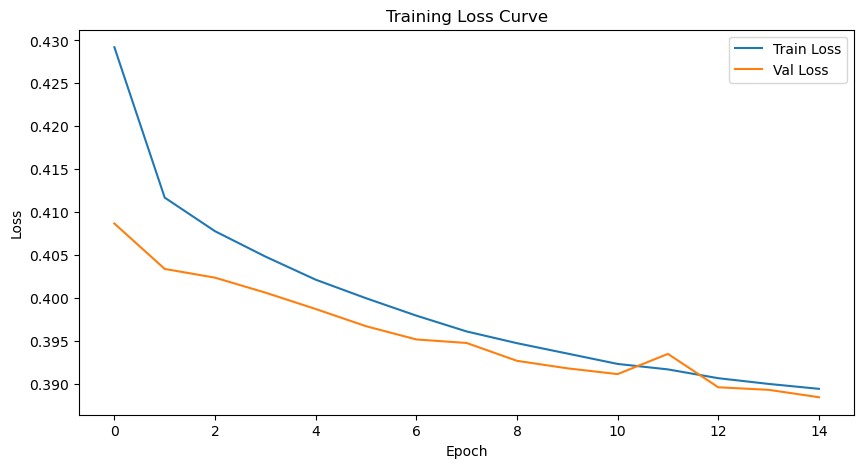

In [7]:
# 损失和优化器（不变）
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# 训练函数（移除 break 和形状打印）
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    num_batches = 0
    for batch_idx, (data, target) in enumerate(tqdm(loader)):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        
        # NaN 监控
        if torch.isnan(loss):
            print(f"Warning: NaN loss at batch {batch_idx}! Check gradients/data.")
            break
        
        loss.backward()
        # 梯度裁剪（防爆炸）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    return total_loss / num_batches if num_batches > 0 else float('inf')

# 验证函数（添加 NaN 检查）
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            if torch.isnan(loss):
                print("Warning: NaN val loss!")
                return float('inf')
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches if num_batches > 0 else float('inf')

# 训练循环
num_epochs = 15
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = val_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    if np.isnan(train_loss) or np.isnan(val_loss):
        print("Training failed: NaN detected. Stop.")
        break

# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curve')
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# 步骤1: 从原始数据取一个样本（假设 wind_combined 和 output_map_2d 已加载且清理）
# 如果你有 scaler_wind 和 scaler_output（从归一化 cell），用它们；否则跳过标准化测试
sample_idx = 0  # 取第0个样本；可改成其他索引
wind_sample_complex = wind_combined[sample_idx]  # (56, 54) complex? 等下，wind_combined 是 (N, 2, 56, 54) float
# 你的 wind_combined 是分离后的 float (N, 2, H, W)，不是 complex。所以直接取 real/imag
wind_sample_real = wind_combined[sample_idx, 0]  # (56, 54) real part
wind_sample_imag = wind_combined[sample_idx, 1]  # (56, 54) imag part

# 步骤2: 标准化输入（匹配训练）
# 展平、transform、恢复形状
wind_sample_flat = np.stack([wind_sample_real, wind_sample_imag], axis=0).reshape(1, -1)  # (1, 2*56*54)
wind_sample_normalized = scaler_wind.transform(wind_sample_flat).reshape(1, 2, 56, 54)  # (1, 2, 56, 54)
wind_sample_tensor = torch.from_numpy(wind_sample_normalized).float().to(device)

# 步骤3: 模型推理
model.eval()
with torch.no_grad():
    env_pred_normalized = model(wind_sample_tensor)  # (1, 1, 56, 54)
    env_pred_normalized_np = env_pred_normalized.squeeze().cpu().numpy()  # (56, 54)

# 步骤4: 反归一化输出（恢复原始尺度）
env_pred_flat = env_pred_normalized_np.reshape(1, -1)  # (1, 56*54)
env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(56, 54)  # (56, 54)

# 假设你已运行模型推理，并有：
# - wind_sample_real: (56, 54) 输入风场 real 部分
# - env_pred_np: (56, 54) 预测波浪场（反归一化后）
# - true_sample: (56, 54) 真实波浪场（从 output_map_2d[sample_idx]）
# - X, Y: meshgrid (56, 54)，Y 是 lat (行), X 是 lon (列)

# 如果没有 true_sample，从数据集中取
sample_idx = 0  # 对应样本索引
true_sample = output_map_2d[sample_idx]  # (56, 54)



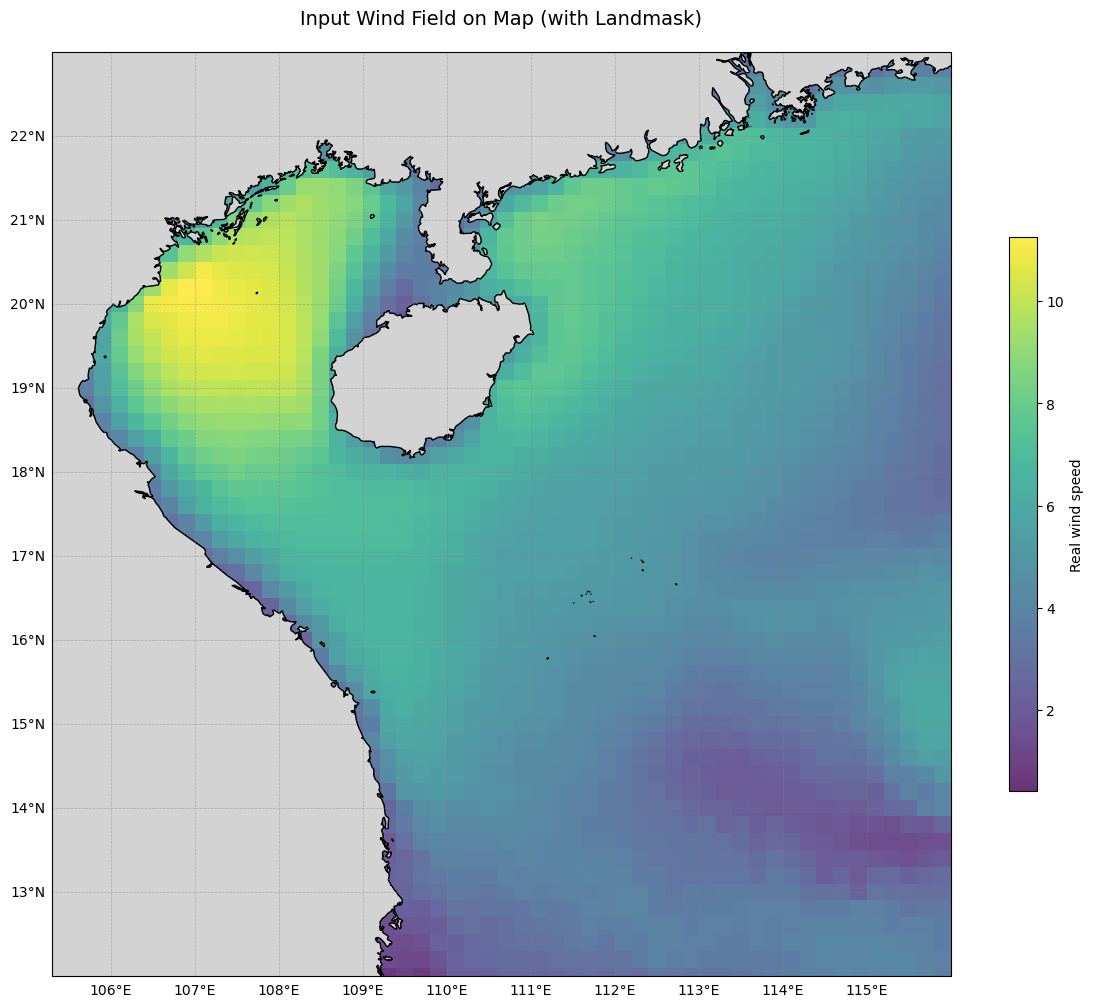

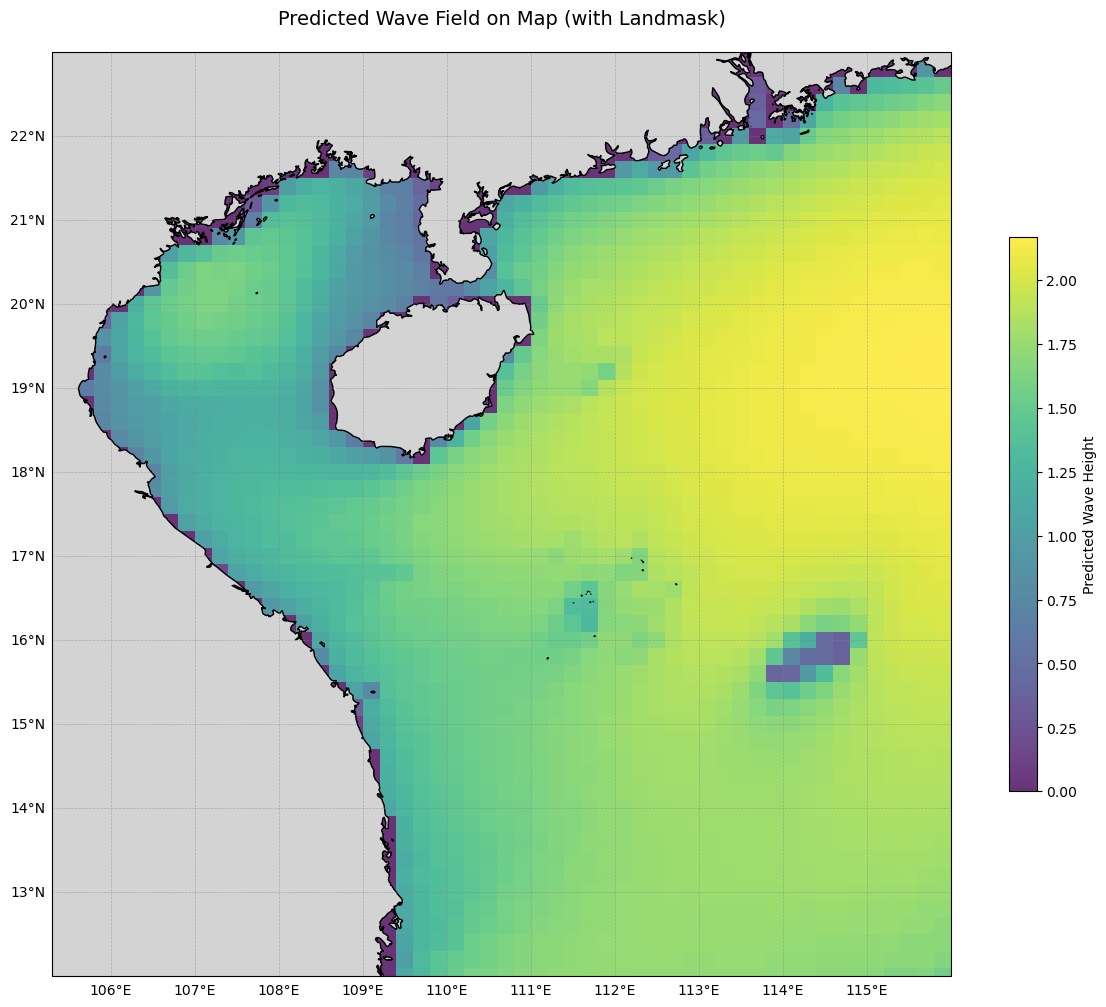

In [9]:
# 风场
wind_field_np = np.sqrt(wind_sample_real**2 + wind_sample_imag**2)  # 计算风速幅值
# 创建地图投影（南海区域）
fig = plt.figure(figsize=(15, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())  # 经纬范围

# 绘制场（pcolormesh 支持经纬网格）
im_pred = ax.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im_pred, ax=ax, label='Real wind speed', shrink=0.6)

# 添加陆地（填充灰色）
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 可选：添加海岸线、边界等
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# 添加经纬度网格线
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlocator = plt.FixedLocator(np.arange(105, 117, 1))  # 经度网格每1度
gl.ylocator = plt.FixedLocator(np.arange(12, 24, 1))    # 纬度网格每1度
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# 添加标题
ax.set_title('Input Wind Field on Map (with Landmask)', fontsize=14, pad=20)

plt.show()


# 预测波浪场
# 创建地图投影（南海区域）
fig = plt.figure(figsize=(15, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())  # 经纬范围

# 绘制预测波浪场（pcolormesh 支持经纬网格）
im_pred = ax.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im_pred, ax=ax, label='Predicted Wave Height', shrink=0.6)

# 添加陆地（填充灰色）
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 可选：添加海岸线、边界等
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# 添加经纬度网格线
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlocator = plt.FixedLocator(np.arange(105, 117, 1))  # 经度网格每1度
gl.ylocator = plt.FixedLocator(np.arange(12, 24, 1))    # 纬度网格每1度
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# 添加标题
ax.set_title('Predicted Wave Field on Map (with Landmask)', fontsize=14, pad=20)

plt.show()




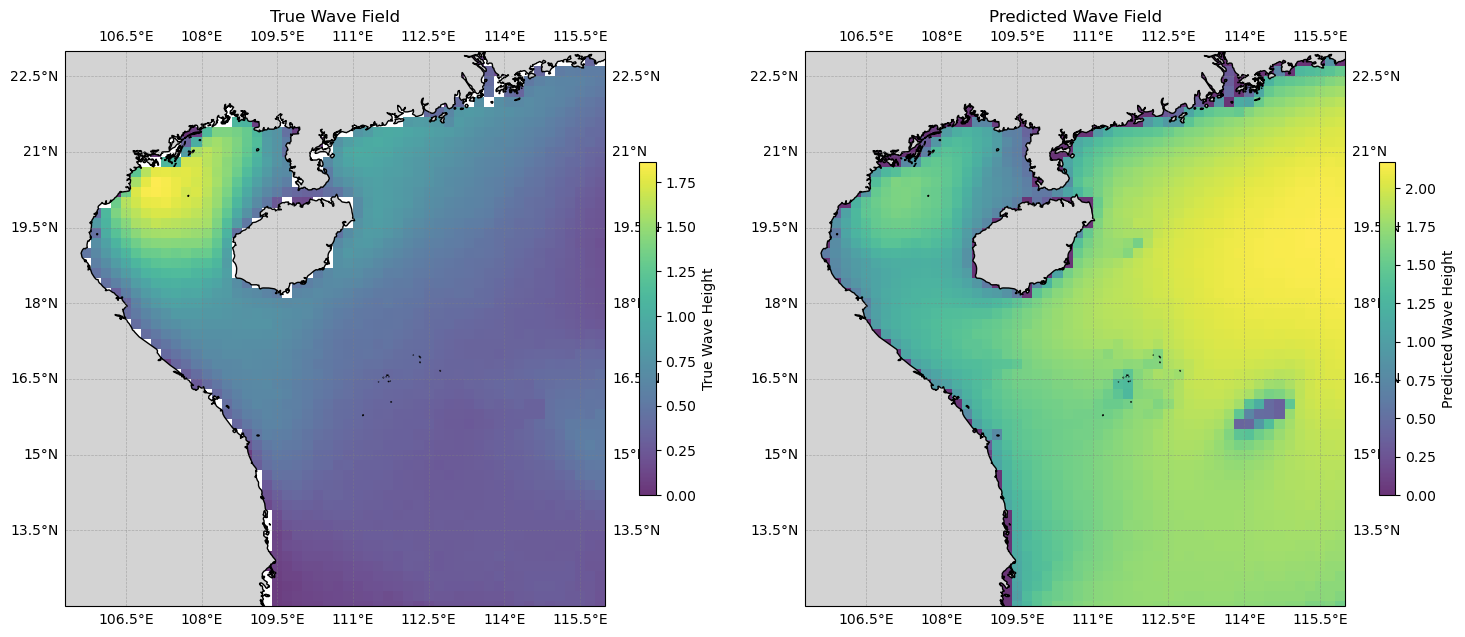

MSE: nan, MAE: nan
Correlation: nan


In [10]:
# 对比图：预测 vs 真实（子图）
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15, 6))

# 真实场
ax1.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
im_true = ax1.pcolormesh(X, Y, true_sample, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
plt.colorbar(im_true, ax=ax1, label='True Wave Height', shrink=0.6)
ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
ax1.set_title('True Wave Field')

# 预测场
ax2.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
im_pred = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
plt.colorbar(im_pred, ax=ax2, label='Predicted Wave Height', shrink=0.6)
ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
ax2.set_title('Predicted Wave Field')

plt.tight_layout()
plt.show()

# 打印对比统计
mse = np.mean((env_pred_np - true_sample)**2)
mae = np.mean(np.abs(env_pred_np - true_sample))
print(f"MSE: {mse:.4f}, MAE: {mae:.4f}")
print(f"Correlation: {np.corrcoef(env_pred_np.flatten(), true_sample.flatten())[0,1]:.4f}")